In [32]:
from pathlib import Path
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
from scipy.stats import lognorm

from standes.analysis.recorders import get_recorder, get_recorders

In [33]:

site = 0
record = 0
ns = 3      # number of stories
stripe = "00pt500"

SITE_FOLDER = Path(f"D:/07_wp1_casestudy_sites/site_{site}")
STOREY_FOLDER = SITE_FOLDER / f"{ns}s"                   
MSA_FOLDER = STOREY_FOLDER / f"mdof/msa_AvgSA_03"
STRIPE_FOLDER = MSA_FOLDER / f"stripe_{stripe}"

PROC_FRAG_FOLDER = Path(r"C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites")

record_log_fp =  STRIPE_FOLDER / f"record_{record}_log.json"
with open(record_log_fp, "r") as file:
    log = json.load(file)

collapse_recorders_fp = STRIPE_FOLDER / f"record_{record}_collapse_recorders.pickle"
with open(collapse_recorders_fp, "rb") as file:
    colrecs = pickle.load(file) 

recorders_fp = STRIPE_FOLDER / f"record_{record}_recorders.pickle"
with open(recorders_fp, "rb") as file:
    recs = pickle.load(file) 

time_arr_fp = STRIPE_FOLDER / f"record_{record}_timearray.pickle"
with open(time_arr_fp, "rb") as file:
    time_arr = pickle.load(file) 


cfc_fp = MSA_FOLDER / "collapse_fragility.json"
with open(cfc_fp, "r") as file:
    msa_fc = json.load(file) 

# Log the AvgSA[0,3] fragility curve from processed results
cfc_fp = PROC_FRAG_FOLDER / f"{ns}s_cbf_dc2_site{site}_collapsefragility_AvgSA_03.json"
with open(cfc_fp, "r") as file:
    idap695_fc = json.load(file) 

In [39]:
ims = np.linspace(0, 1, 50) # in g
g = 9810    # mm/s²
msa_fc_fit = lognorm.cdf(ims, s=msa_fc["dispersion"], scale=msa_fc["median"])
idap695_fc_fit = lognorm.cdf(ims * g, s=idap695_fc["dispersion"], scale=idap695_fc["median"])

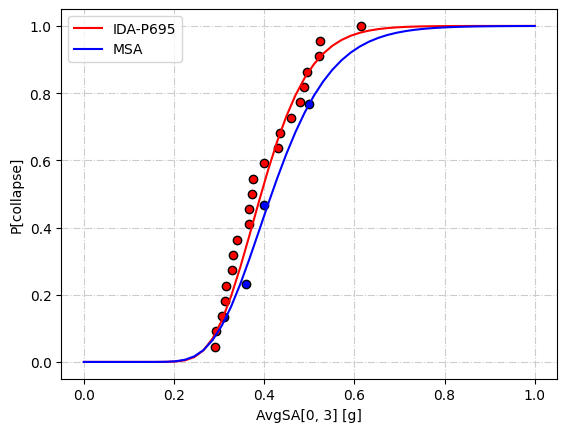

In [43]:
fig, ax = plt.subplots()
ax.plot(msa_fc["efc"][0], msa_fc["efc"][1], ls="none", marker="o", mfc="b", mec="k")
ax.plot(np.array(idap695_fc["efc"][0]) / g, idap695_fc["efc"][1], ls="none", marker="o", mfc="r", mec="k")
ax.plot(ims, idap695_fc_fit, color="r", label="IDA-P695")
ax.plot(ims, msa_fc_fit, color="b", label="MSA")
ax.set_xlabel("AvgSA[0, 3] [g]")
ax.set_ylabel("P[collapse]")
ax.grid(ls="-.", color="0.8")
ax.legend()

In [36]:
IDAP695_FOLDER

WindowsPath('D:/07_wp1_casestudy_sites/site_0/3s/mdof/ida_femap695')